In [116]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

In [117]:
df = pd.read_csv('/content/heart.csv')

In [118]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [119]:
X = df.iloc[:,0:-1]
y = df.iloc[:,-1]

In [120]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

(242, 13)
(61, 13)


In [121]:
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
svc = SVC()
lr = LogisticRegression()

In [122]:
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.8360655737704918

In [123]:
gb.fit(X_train,y_train)
y_pred = gb.predict(X_test)
accuracy_score(y_test,y_pred)

0.7704918032786885

In [124]:
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
accuracy_score(y_test,y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8852459016393442

In [125]:
rf = RandomForestClassifier(max_samples=0.75,random_state=42)
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.9016393442622951

In [126]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(RandomForestClassifier(max_samples=0.75),X,y,cv=10,scoring='accuracy'))

np.float64(0.8347311827956989)

In [127]:
# Number of trees in random forest
n_estimators = [20,60,100,120]

# Number of features to consider at every split
max_features = [0.2,0.6,1.0]

# Maximum number of levels in tree
max_depth = [2,8,None]

# Number of samples
max_samples = [0.5,0.75,1.0]

In [128]:
param_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
              'max_samples':max_samples
             }
print(param_grid)

{'n_estimators': [20, 60, 100, 120], 'max_features': [0.2, 0.6, 1.0], 'max_depth': [2, 8, None], 'max_samples': [0.5, 0.75, 1.0]}


In [129]:
rf = RandomForestClassifier()
from sklearn.model_selection import GridSearchCV

rf_grid = GridSearchCV(estimator = rf,
                       param_grid = param_grid,
                       cv = 5,
                       verbose=2,
                       n_jobs = -1)

In [130]:
rf_grid.fit(X_train,y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [2, 8, None],
                         'max_features': [0.2, 0.6, 1.0],
                         'max_samples': [0.5, 0.75, 1.0],
                         'n_estimators': [20, 60, 100, 120]},
             verbose=2)

In [131]:
rf_grid.best_params_

{'max_depth': 2, 'max_features': 0.2, 'max_samples': 0.75, 'n_estimators': 100}

In [132]:
rf_grid.best_score_

np.float64(0.843027210884354)

In [133]:
# Number of trees in random forest
n_estimators = [20,60,100,120]

# Number of features to consider at every split
max_features = [0.2,0.6,1.0]

# Maximum number of levels in tree
max_depth = [2,8,None]

# Number of samples
max_samples = [0.5,0.75,1.0]

# Bootstrap samples
bootstrap = [True,False]

# Minimum number of samples required to split a node
min_samples_split = [2, 5]

# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2]

In [134]:
param_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
              'max_samples':max_samples,
              'bootstrap':bootstrap,
              'min_samples_split':min_samples_split,
              'min_samples_leaf':min_samples_leaf
             }
print(param_grid)

{'n_estimators': [20, 60, 100, 120], 'max_features': [0.2, 0.6, 1.0], 'max_depth': [2, 8, None], 'max_samples': [0.5, 0.75, 1.0], 'bootstrap': [True, False], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}


In [135]:
from sklearn.model_selection import RandomizedSearchCV

rf_grid = RandomizedSearchCV(estimator = rf,
                       param_distributions = param_grid,
                       cv = 5,
                       verbose=2,
                       n_jobs = -1)
rf_grid.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py", line 431, in fit
    raise ValueError(
ValueError:

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [2, 8, None],
                                        'max_features': [0.2, 0.6, 1.0],
                                        'max_samples': [0.5, 0.75, 1.0],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [20, 60, 100, 120]},
                   verbose=2)

In [136]:
rf_grid.best_params_

{'n_estimators': 60,
 'min_samples_split': 2,
 'min_samples_leaf': 2,
 'max_samples': 1.0,
 'max_features': 1.0,
 'max_depth': 8,
 'bootstrap': True}

In [137]:
rf_grid.best_score_

np.float64(0.8140306122448979)

In [138]:
from sklearn.datasets import make_classification
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [139]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.094766,0.503756,0.087514,-1.168997,-1.094300,1
1,0.791107,-0.280157,-1.776443,0.640283,0.253738,1
2,-1.704896,-0.608166,-1.779523,0.398527,-1.861147,0
3,0.276876,0.723594,-2.741964,2.315725,-1.042096,0
4,-1.239105,-2.220121,0.057911,0.702167,-0.607667,0


In [140]:
import random

def sample_row(df,size):
  return df.sample(int(size*df.shape[0]),replace=True)

def sample_col(df,size):
  cols = random.sample(df.columns.tolist()[:-1],int(size*(df.shape[1]-1)))
  new_df = df[cols].copy()  # Added .copy() here to avoid SettingWithCopyWarning
  new_df['target'] = df['target']
  return new_df

def combine_df(df1,row_percent,col_percent):
  new_df = sample_row(df,row_percent)
  return sample_col(new_df,col_percent)

In [141]:
df1 = sample_row(df,0.2)
df2 = sample_row(df,0.2)
df3 = sample_row(df,0.2)

In [154]:
df1 = sample_col(df,0.4)
df2 = sample_col(df,0.4)
df3 = sample_col(df,0.4)

In [143]:
df1 = combine_df(df, 0.2, 0.6)
df2 = combine_df(df, 0.2, 0.6)
df3 = combine_df(df, 0.2, 0.6)

In [155]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col1', 'col5', 'target'], dtype='object')
Index(['col3', 'col2', 'target'], dtype='object')
Index(['col5', 'col3', 'target'], dtype='object')


In [156]:
df2

,col3,col2,target
0,0.087514,0.503756,1
1,-1.776443,-0.280157,1
2,-1.779523,-0.608166,0
3,-2.741964,0.723594,0
4,0.057911,-2.220121,0
...,...,...,...
95,-0.358296,-1.287841,0
96,0.114544,-5.438846,1
97,-2.423650,-1.236850,0
98,-1.661127,0.104282,0


In [157]:
df3

,col5,col3,target
0,-1.094300,0.087514,1
1,0.253738,-1.776443,1
2,-1.861147,-1.779523,0
3,-1.042096,-2.741964,0
4,-0.607667,0.057911,0
...,...,...,...
95,-2.087738,-0.358296,0
96,-2.407439,0.114544,1
97,-1.275573,-2.423650,0
98,-2.666529,-1.661127,0


In [158]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()


clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

[Text(0.6041666666666666, 0.9444444444444444, 'x[0] <= 0.385\ngini = 0.5\nsamples = 100\nvalue = [51, 49]'),
 Text(0.3333333333333333, 0.8333333333333334, 'x[0] <= -0.6\ngini = 0.387\nsamples = 61\nvalue = [45, 16]'),
 Text(0.46875, 0.8888888888888888, 'True  '),
 Text(0.16666666666666666, 0.7222222222222222, 'x[1] <= 1.303\ngini = 0.255\nsamples = 40\nvalue = [34, 6]'),
 Text(0.125, 0.6111111111111112, 'x[1] <= -1.006\ngini = 0.188\nsamples = 38\nvalue = [34, 4]'),
 Text(0.08333333333333333, 0.5, 'gini = 0.0\nsamples = 22\nvalue = [22, 0]'),
 Text(0.16666666666666666, 0.5, 'x[1] <= -0.682\ngini = 0.375\nsamples = 16\nvalue = [12, 4]'),
 Text(0.08333333333333333, 0.3888888888888889, 'x[0] <= -1.799\ngini = 0.48\nsamples = 5\nvalue = [2, 3]'),
 Text(0.041666666666666664, 0.2777777777777778, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.125, 0.2777777777777778, 'x[0] <= -0.922\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.08333333333333333, 0.16666666666666666, 'gini = 0.0\

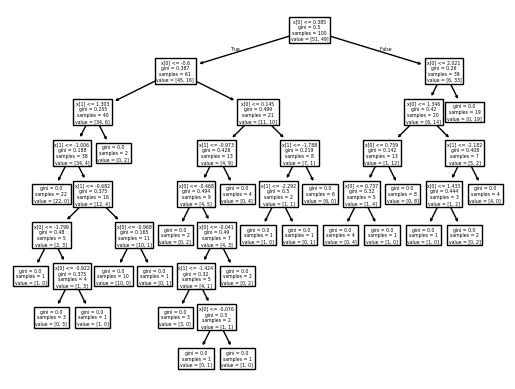

In [159]:
from sklearn.tree import plot_tree
plot_tree(clf1)

[Text(0.4730603448275862, 0.9642857142857143, 'x[1] <= -2.67\ngini = 0.5\nsamples = 100\nvalue = [51, 49]'),
 Text(0.2974137931034483, 0.8928571428571429, 'x[0] <= 1.657\ngini = 0.117\nsamples = 16\nvalue = [1, 15]'),
 Text(0.38523706896551724, 0.9285714285714286, 'True  '),
 Text(0.2629310344827586, 0.8214285714285714, 'gini = 0.0\nsamples = 14\nvalue = [0, 14]'),
 Text(0.33189655172413796, 0.8214285714285714, 'x[0] <= 2.207\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.2974137931034483, 0.75, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.36637931034482757, 0.75, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6487068965517241, 0.8928571428571429, 'x[0] <= -3.628\ngini = 0.482\nsamples = 84\nvalue = [50, 34]'),
 Text(0.5608836206896551, 0.9285714285714286, '  False'),
 Text(0.6142241379310345, 0.8214285714285714, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.6831896551724138, 0.8214285714285714, 'x[0] <= 0.377\ngini = 0.472\nsamples = 81\nvalue = [50, 31]'),
 Tex

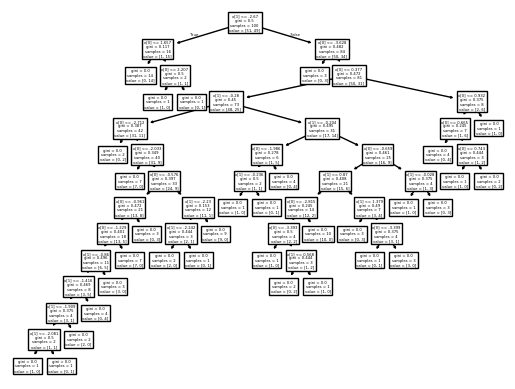

In [160]:
plot_tree(clf2)

[Text(0.7216981132075472, 0.9375, 'x[1] <= 0.377\ngini = 0.5\nsamples = 100\nvalue = [51, 49]'),
 Text(0.5188679245283019, 0.8125, 'x[0] <= -0.983\ngini = 0.49\nsamples = 84\nvalue = [48, 36]'),
 Text(0.6202830188679245, 0.875, 'True  '),
 Text(0.22641509433962265, 0.6875, 'x[1] <= -1.029\ngini = 0.395\nsamples = 48\nvalue = [35, 13]'),
 Text(0.07547169811320754, 0.5625, 'x[0] <= -1.701\ngini = 0.062\nsamples = 31\nvalue = [30, 1]'),
 Text(0.03773584905660377, 0.4375, 'gini = 0.0\nsamples = 19\nvalue = [19, 0]'),
 Text(0.11320754716981132, 0.4375, 'x[0] <= -1.68\ngini = 0.153\nsamples = 12\nvalue = [11, 1]'),
 Text(0.07547169811320754, 0.3125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.1509433962264151, 0.3125, 'gini = 0.0\nsamples = 11\nvalue = [11, 0]'),
 Text(0.37735849056603776, 0.5625, 'x[0] <= -1.451\ngini = 0.415\nsamples = 17\nvalue = [5, 12]'),
 Text(0.2641509433962264, 0.4375, 'x[0] <= -2.122\ngini = 0.165\nsamples = 11\nvalue = [1, 10]'),
 Text(0.22641509433962265, 

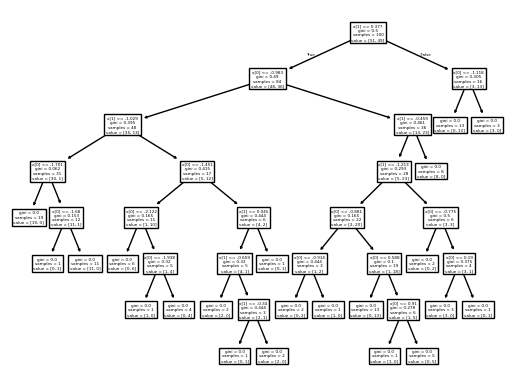

In [161]:
plot_tree(clf3)

In [162]:
clf1.predict(np.array([1.949046	,-1.430851	]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [163]:
clf2.predict(np.array([1.949046	,-1.430851]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [164]:
clf3.predict(np.array([1.949046 ,	-1.430851]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [165]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1)

# Extract data and labels
X, y = mnist["data"], mnist["target"]

In [166]:
X

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [167]:
y

,class
0,5
1,0
2,4
3,1
4,9
...,...
69995,2
69996,3
69997,4
69998,5


<Axes: >

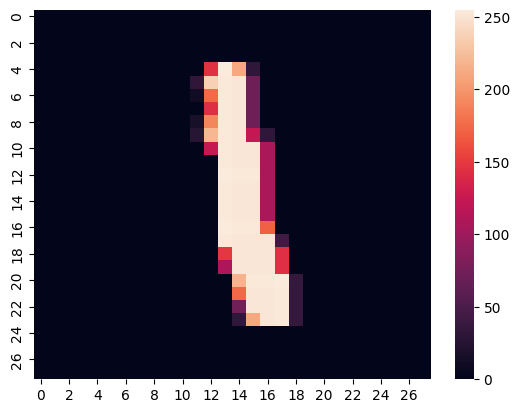

In [175]:
sns.heatmap(X.iloc[6].values.reshape(28,28))

In [171]:
clf = RandomForestClassifier()

In [172]:
clf.fit(X,y)

RandomForestClassifier()

In [173]:
clf.feature_importances_.shape

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 3.13908314e-07, 6.16083956e-07, 3.08400349e-07,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 6.17619314e-07, 2.76747762e-07,
       1.81133562e-06, 3.95000204e-06, 2.73830382e-06, 5.83918736e-06,
       6.57884652e-06, 2.36357590e-06, 4.37031963e-06, 8.00142918e-06,
       2.04097400e-06, 1.95765249e-06, 3.06820664e-07, 1.58787732e-07,
       1.33060790e-06, 0.00000000e+00, 5.75773236e-07, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

<Axes: >

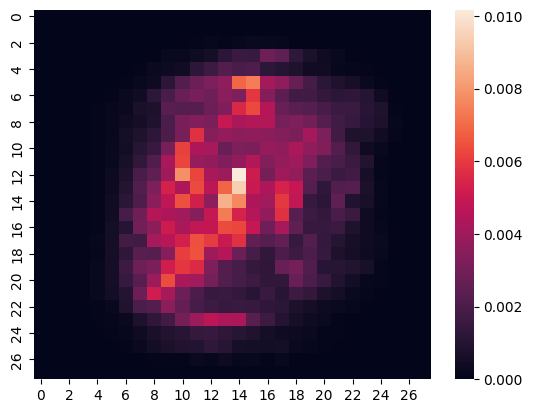

In [174]:
sns.heatmap(clf.feature_importances_.reshape(28,28))